# 🏙️ Berlin Housing Price Prediction (2026)

### 📌 Objective
Build a machine learning model to predict rental prices in Berlin using property features.

### 🧰 Tools Used
- Python (Pandas, NumPy)
- Visualization (Matplotlib, Seaborn)
- Machine Learning (Scikit-learn)

### 📊 Dataset
Berlin rental listings dataset containing property details, pricing, and features.
_____

## 📦 Importing Required Libraries

This section imports all necessary libraries for data manipulation, visualization, and modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

%matplotlib inline 

## 📂 Loading and Inspecting Data

- Load dataset
- Check shape and structure
- Preview sample rows

In [2]:
df = pd.read_csv(
    'berlin.csv',
    engine='python',
    encoding='latin1',
    on_bad_lines='skip'
)
print(df.shape)
print(df.head())
df.info()

(12349, 49)
   regio1 serviceCharge       heatingType telekomTvOffer  \
0  Berlin         320.0   central_heating            NaN   
1  Berlin          79.0   central_heating  ONE_YEAR_FREE   
2  Berlin         150.0     floor_heating  ONE_YEAR_FREE   
3  Berlin        228.78     floor_heating            NaN   
4  Berlin        147.08  district_heating  ONE_YEAR_FREE   

   telekomHybridUploadSpeed newlyConst balcony picturecount  pricetrend  \
0                       NaN      False    True           10        4.99   
1                       NaN      False   False           17        7.35   
2                       NaN       True    True           15        6.60   
3                       NaN      False    True            2        8.63   
4                       NaN       True    True            9        7.56   

   telekomUploadSpeed  ...  regio2                 regio3  \
0                 NaN  ...  Berlin        Staaken_Spandau   
1                40.0  ...  Berlin  WeiÃensee_WeiÃen

## 🔍 Initial Observations

- Dataset contains ~12K rows and multiple features
- Mix of numerical and categorical data
- Missing values present in several columns
- Target variable: `totalRent`

## 🧹 Data Cleaning

- Convert columns to numeric where possible
- Handle inconsistent data types

In [3]:
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

## 📊 Exploratory Data Analysis (EDA)

Understanding relationships between variables:

- Distribution of rent
- Rent vs living space
- Correlation between features

count     9744.000000
mean      1385.341741
std       1129.695296
min          0.000000
25%        790.000000
50%       1124.000000
75%       1685.217500
max      51570.000000
Name: totalRent, dtype: float64


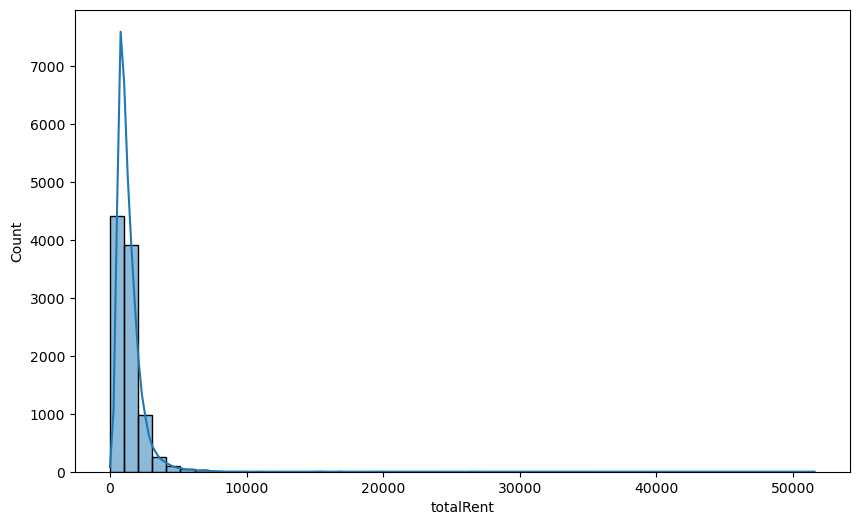

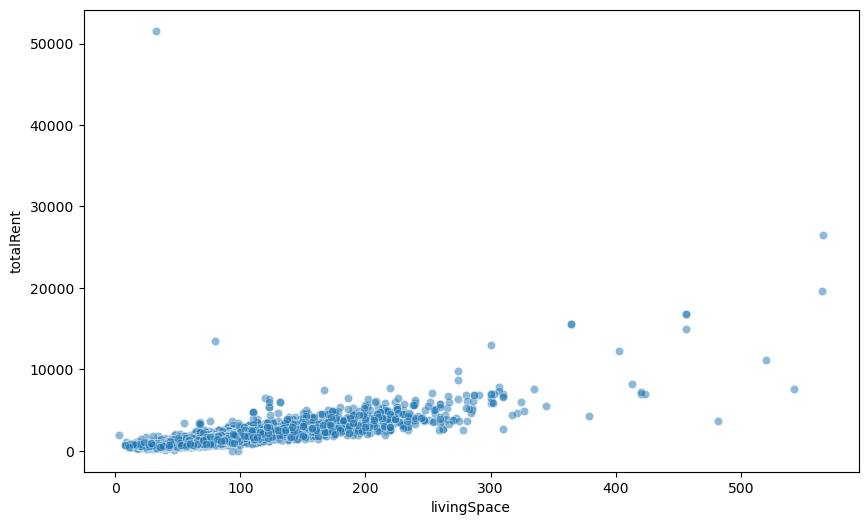

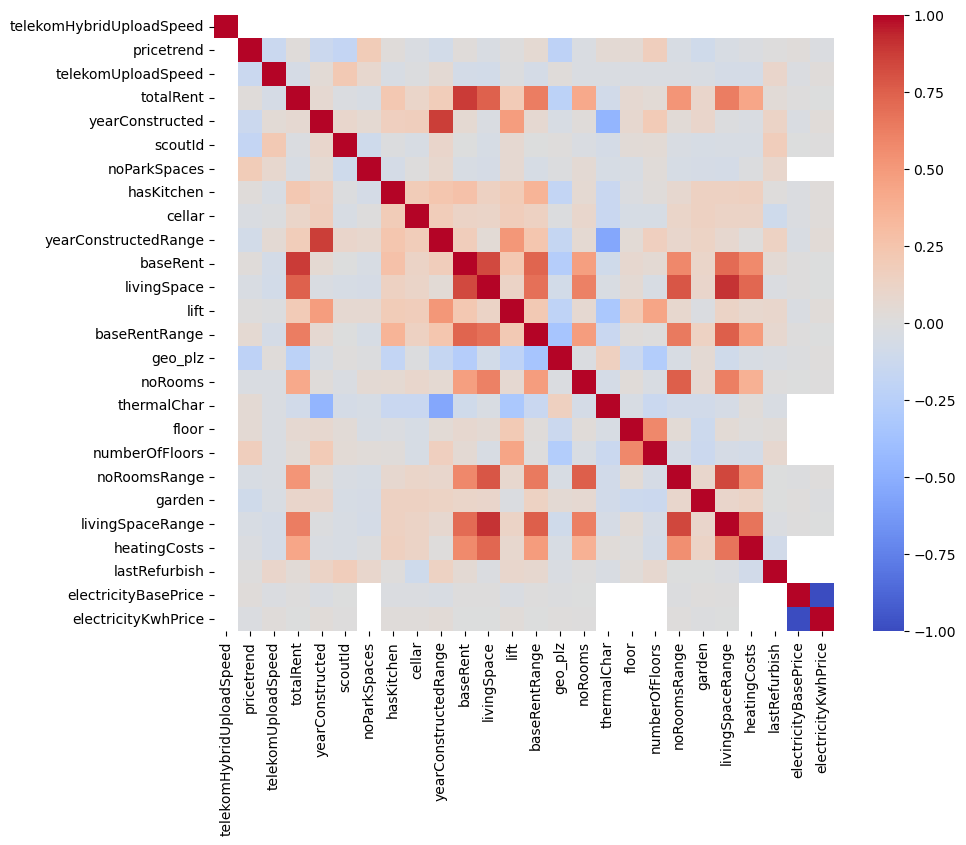

In [4]:
print(df['totalRent'].describe())

plt.figure(figsize=(10,6))
sns.histplot(df['totalRent'], bins=50, kde=True)
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='livingSpace', y='totalRent', alpha=0.5)
plt.show()

numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.show()

### 🔑 Key Insights

- Rent is right-skewed (few expensive outliers)
- Strong relationship between living space and rent
- Presence of outliers justified removing top 1% rent values

## 🛠 Feature Engineering & Cleaning

- Dropping irrelevant columns
- Handling missing values
- Creating new feature: `age` (property age)
- Removing extreme outliers (top 1% rent)

In [5]:
drop_cols = ['scoutId', 'description', 'facilities', 'street', 'houseNumber', 
             'streetPlain', 'date', 'regio1', 'regio2', 
             'geo_bln', 'geo_krs', 'baseRentRange', 'livingSpaceRange', 
             'noRoomsRange', 'picturecount', 'pricetrend', 
             'telekomUploadSpeed', 'telekomHybridUploadSpeed', 'telekomTvOffer']

df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')

df = df.dropna(subset=['totalRent', 'livingSpace'])

from datetime import datetime
df['age'] = datetime.now().year - df['yearConstructed']

df = df[df['totalRent'] < df['totalRent'].quantile(0.99)]

print(df.shape)

(9645, 31)


## ⚙️ Feature Engineering & Pipeline

- Splitting features into numerical & categorical
- Handling missing values
- Scaling numerical features
- Encoding categorical variables

## ✂️ Train-Test Split

Splitting dataset into training (80%) and testing (20%) sets to evaluate model performance on unseen data.

In [6]:
X = df.drop('totalRent', axis=1)
y = df['totalRent']

numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object','bool']).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 🤖 Model Training

Two models are used:

- Linear Regression (baseline model)
- Random Forest (advanced model)

In [7]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

## 📏 Model Evaluation

Metrics used:

- RMSE (Root Mean Squared Error)
- R² Score (Model accuracy)

In [8]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} - RMSE: €{rmse:.2f} | R²: {r2:.4f}")

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")

Linear Regression - RMSE: €89.46 | R²: 0.9861
Random Forest - RMSE: €93.40 | R²: 0.9848


### 🧠 Results Interpretation

- Both models perform very well (R² ≈ 0.98)
- Linear Regression slightly outperforms Random Forest
- Indicates strong linear relationship in data

## 📈 Actual vs Predicted Prices

Visual comparison of predicted vs actual rent values.

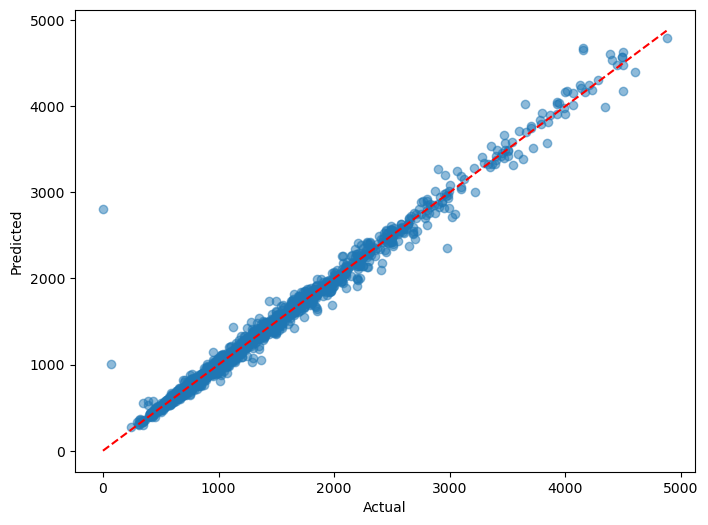

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## 🌟 Feature Importance Analysis

Understanding which features influence rent the most.

num__baseRent                                      0.986391
num__livingSpace                                   0.004309
num__heatingCosts                                  0.001481
num__geo_plz                                       0.000597
cat__serviceCharge_0.0                             0.000513
num__numberOfFloors                                0.000420
num__thermalChar                                   0.000339
cat__heatingType_self_contained_central_heating    0.000284
cat__serviceCharge_150.0                           0.000261
num__noRooms                                       0.000257
num__floor                                         0.000244
num__age                                           0.000210
cat__serviceCharge_365.0                           0.000209
num__yearConstructed                               0.000204
cat__petsAllowed_yes                               0.000181
dtype: float64


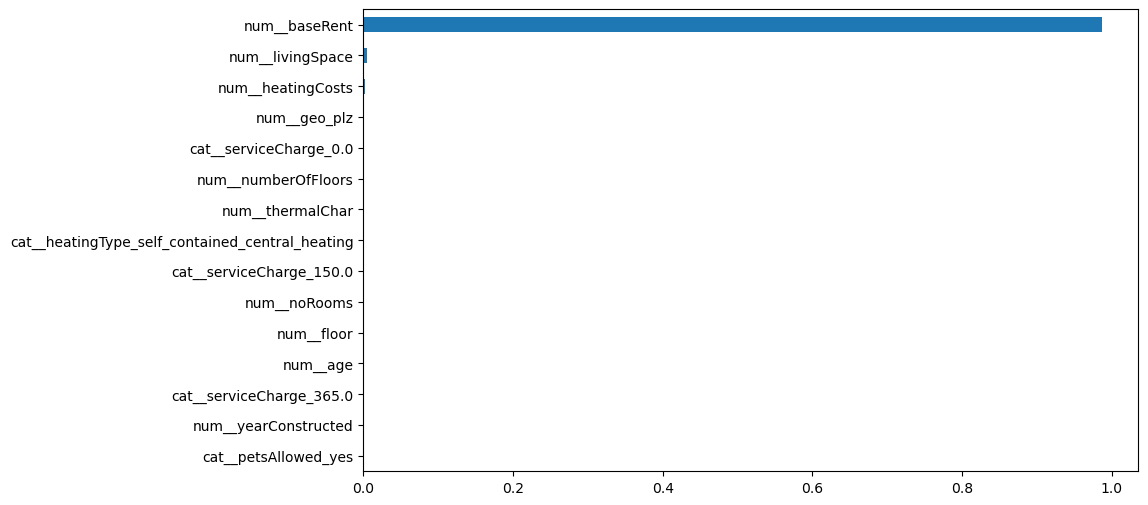

In [10]:
rf_model = rf_pipeline.named_steps['regressor']
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print(feat_imp.head(15))

plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.show()

### 🔑 Insights

- `baseRent` dominates prediction, suggesting total rent is largely derived from base rent + additional costs
- `livingSpace` significantly impacts pricing
- Other features contribute minimally

## 🧾 Conclusion

This project demonstrates:

- End-to-end ML pipeline for real estate pricing
- Strong predictive performance using structured data
- Key drivers of rent in Berlin housing market

### ⚠️ Limitations

- Model heavily depends on `baseRent`
- External factors like location quality, demand trends not fully captured
- Data may not reflect real-time 2026 market dynamics

### 📌 Real-World Use

- Helps renters estimate fair prices
- Assists landlords in pricing properties
- Useful for real estate analytics platforms